## 1. Setup and Imports

This first code cell imports all the necessary libraries for the project:
* `networkx` (as `nx`) for graph loading and analysis.
* `numpy` (as `np`) for numerical operations and matrices.
* `matplotlib.pyplot` (as `plt`) for all visualizations.
* `scipy.linalg.eigh` for efficient eigenvalue calculations on symmetric matrices.
* `queue` to manage the list of communities to be processed.

It also loads the famous **Zachary's Karate Club Graph** (`G`), pre-computes global values like the total number of nodes (`n`) and edges (`m`), and creates a fixed **spring layout** (`pos`). This fixed layout is essential for ensuring our visualizations are consistent and easy to compare across iterations.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh  # Use for symmetric matrices
import queue

# --- 1. Load the Graph ---
G = nx.karate_club_graph()
print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

# --- 2. Pre-computation for the whole graph ---
# We need the global 'm' and global degrees 'k' for all calculations 
m = G.number_of_edges()
k = dict(G.degree())
n = G.number_of_nodes()

# --- 3. Create a fixed layout for consistent visualizations [cite: 164] ---
# A fixed layout is crucial for seeing how communities split.
pos = nx.spring_layout(G, seed=42)

Graph loaded: 34 nodes, 78 edges.


## 2. Core Modularity Functions

This cell defines the two most important functions for the spectral algorithm.

* `get_restricted_modularity_matrix(G, node_list)`: This function calculates the **restricted modularity matrix ($B^{(C)}$)** for a specific community (given as `node_list`). As per the assignment, this matrix is $B^{(C)}_{ij} = A_{ij} - \frac{k_i k_j}{2m}$ for all nodes $i, j$ within the community $C$.
* `get_leading_eigenpair(matrix)`: This is a helper function that takes a symmetric matrix (like $B^{(C)}$) and returns its **leading eigenpair**—the eigenvalue with the largest magnitude ($\lambda_1$) and its corresponding eigenvector ($u_1$). This pair determines if a split should happen and, if so, how.

In [2]:
def get_restricted_modularity_matrix(G, node_list):
    """
    Computes the modularity matrix B^(C) for a given set of nodes (a community C).
    
    The formula is B_ij^(C) = A_ij - (k_i * k_j) / (2m) for i,j in C 
    """
    
    sub_n = len(node_list)
    B_sub = np.zeros((sub_n, sub_n))
    
    # Create a mapping from node_list index to node_id
    node_map = {node_list[i]: i for i in range(sub_n)}
    
    # Get the subgraph to easily check for edges (A_ij)
    subG = G.subgraph(node_list)
    
    for i in range(sub_n):
        for j in range(i, sub_n): # Only compute upper triangle
            node_i = node_list[i]
            node_j = node_list[j]
            
            # Get A_ij from the subgraph
            A_ij = 1 if subG.has_edge(node_i, node_j) else 0
            
            # Get global degrees k_i, k_j and global m
            k_i = k[node_i]
            k_j = k[node_j]
            
            # Calculate B_ij 
            B_ij = A_ij - (k_i * k_j) / (2 * m)
            
            B_sub[i, j] = B_ij
            B_sub[j, i] = B_ij # Matrix is symmetric
            
    return B_sub

def get_leading_eigenpair(matrix):
    """
    Finds the leading eigenvalue and eigenvector.
    'eigh' is used for symmetric matrices and returns sorted eigenvalues.
    """
    eigenvalues, eigenvectors = eigh(matrix)
    
    # The leading eigenpair is the one with the largest eigenvalue
    lambda_1 = eigenvalues[-1]
    u_1 = eigenvectors[:, -1]
    
    return lambda_1, u_1

## 3. Metrics and State Collection

This cell contains the `compute_and_store_metrics` function. Its purpose is to compute and store all the required metrics at any given iteration of the algorithm.

Following the assignment, this function calculates four key metrics for the **entire original graph `G`**:
1.  Degree Centrality
2.  Betweenness Centrality
3.  Closeness Centrality
4.  Clustering Coefficient

It also creates a `community_map`, which maps each node to its current community ID. This map is used to color the nodes in our visualizations. The function returns a dictionary containing all this information.

In [3]:
def compute_and_store_metrics(G, current_communities):
    """
    Computes all required metrics and the current community assignments.
    """
    
    # 1. Create a map of {node: community_id} for coloring
    community_map = {}
    for i, comm_nodes in enumerate(current_communities):
        for node in comm_nodes:
            community_map[node] = i
    
    # 2. Compute metrics using networkx [cite: 168]
    metrics = {
        'degree': nx.degree_centrality(G),       # [cite: 171]
        'betweenness': nx.betweenness_centrality(G), # [cite: 176]
        'closeness': nx.closeness_centrality(G),   # [cite: 181]
        'clustering': nx.clustering(G)          # [cite: 186]
    }
    
    return {
        'community_map': community_map,
        'metrics': metrics
    }

## 4. The Recursive Bisection Algorithm

This is the main driver of the project. This cell executes the complete iterative algorithm. Instead of using a pure recursive function, we use a **Queue** (`communities_to_process`) to manage the communities that still need to be evaluated.

The process is as follows:
1.  **Initialize**: Start with one community (the entire graph) and add it to the queue. Store this "Iteration 0" state.
2.  **Loop**: While the queue is not empty:
    * Get the next community `C` to process.
    * Compute its restricted modularity matrix $B^{(C)}$.
    * Find its leading eigenpair ($\lambda_1, u_1$).
3.  **Check Stop Criterion**:
    * If **$\lambda_1 \le 0$**, the community is indivisible. It is moved to the `final_communities` set and we do not process it further.
    * If **$\lambda_1 > 0$**, a split is beneficial.
4.  **Split**: The community is split into two new sub-communities (`c_plus` and `c_minus`) based on the *sign* of the entries in the eigenvector $u_1$.
5.  **Store and Enqueue**: The new sub-communities are added back to the queue to be processed, and the state of the graph at this new iteration is computed and stored in `iteration_results`.

The loop continues until the queue is empty, at which point all communities have been finalized.

In [4]:
# --- 1. Initialization ---
# Start with all nodes in one community
communities_to_process = queue.Queue()
initial_community = frozenset(G.nodes())
communities_to_process.put(initial_community)

# This set will hold all "final" communities (those that are indivisible)
final_communities = set()

# This list will store the state of the graph at each iteration for plotting
iteration_results = []
iteration_count = 0

# Store the initial state (Iteration 0: 1 community)
current_community_set = {initial_community}
iteration_results.append(compute_and_store_metrics(G, current_community_set))
print("--- Starting Community Detection ---")
print(f"Iteration {iteration_count}: {len(current_community_set)} communities")

# --- 2. Iterative Splitting Loop ---
while not communities_to_process.empty():
    
    # Get the next community to test
    current_nodes_set = communities_to_process.get()
    
    # If the community is trivial (1 node), it's final.
    if len(current_nodes_set) <= 1:
        final_communities.add(current_nodes_set)
        continue
        
    current_nodes_list = list(current_nodes_set)
    
    # --- 3. Compute B^(C) and Eigenpair [cite: 124, 127] ---
    B_sub = get_restricted_modularity_matrix(G, current_nodes_list)
    lambda_1, u_1 = get_leading_eigenpair(B_sub)
    
    # --- 4. Eigenvalue Stopping Criterion  ---
    # If lambda_1 <= 0, the community is indivisible and increases modularity.
    if lambda_1 <= 1e-10: # Use a small epsilon for float comparison
        final_communities.add(current_nodes_set)
        
    else:
        # --- 5. Split the community [cite: 159] ---
        iteration_count += 1
        
        c_plus = frozenset({current_nodes_list[i] for i, val in enumerate(u_1) if val > 0})
        c_minus = frozenset({current_nodes_list[i] for i, val in enumerate(u_1) if val <= 0})
        
        # Handle rare case of an empty split (all u_1 entries same sign)
        if not c_plus or not c_minus:
            final_communities.add(current_nodes_set)
            continue
            
        # --- 6. Update Community List and Queue ---
        # Add the two new, smaller communities to be processed
        communities_to_process.put(c_plus)
        communities_to_process.put(c_minus)
        
        # Update the 'current_community_set' for visualization
        # We remove the old big community and add the two new small ones
        current_community_set.remove(current_nodes_set)
        current_community_set.add(c_plus)
        current_community_set.add(c_minus)
        
        # --- 7. Store results for this iteration ---
        iteration_results.append(compute_and_store_metrics(G, current_community_set))
        print(f"Iteration {iteration_count}: {len(current_community_set)} communities")

print("--- Community Detection Complete ---")
print(f"Found {len(final_communities)} final communities.")

--- Starting Community Detection ---
Iteration 0: 1 communities
Iteration 1: 2 communities
Iteration 2: 3 communities
Iteration 3: 4 communities
Iteration 7: 5 communities
--- Community Detection Complete ---
Found 5 final communities.


## 5. Visualization 1: Community Splits

This cell visualizes the first main requirement: plotting the graph at each iteration.

It iterates through the `iteration_results` list (which we saved in the previous step) and creates a subplot for each state. Using the fixed `pos` layout and the `community_map` stored for each iteration, it draws the graph with nodes colored according to their community. This allows us to see exactly how the graph splits apart at each step of the algorithm.


--- Visualizing Community Splits ---


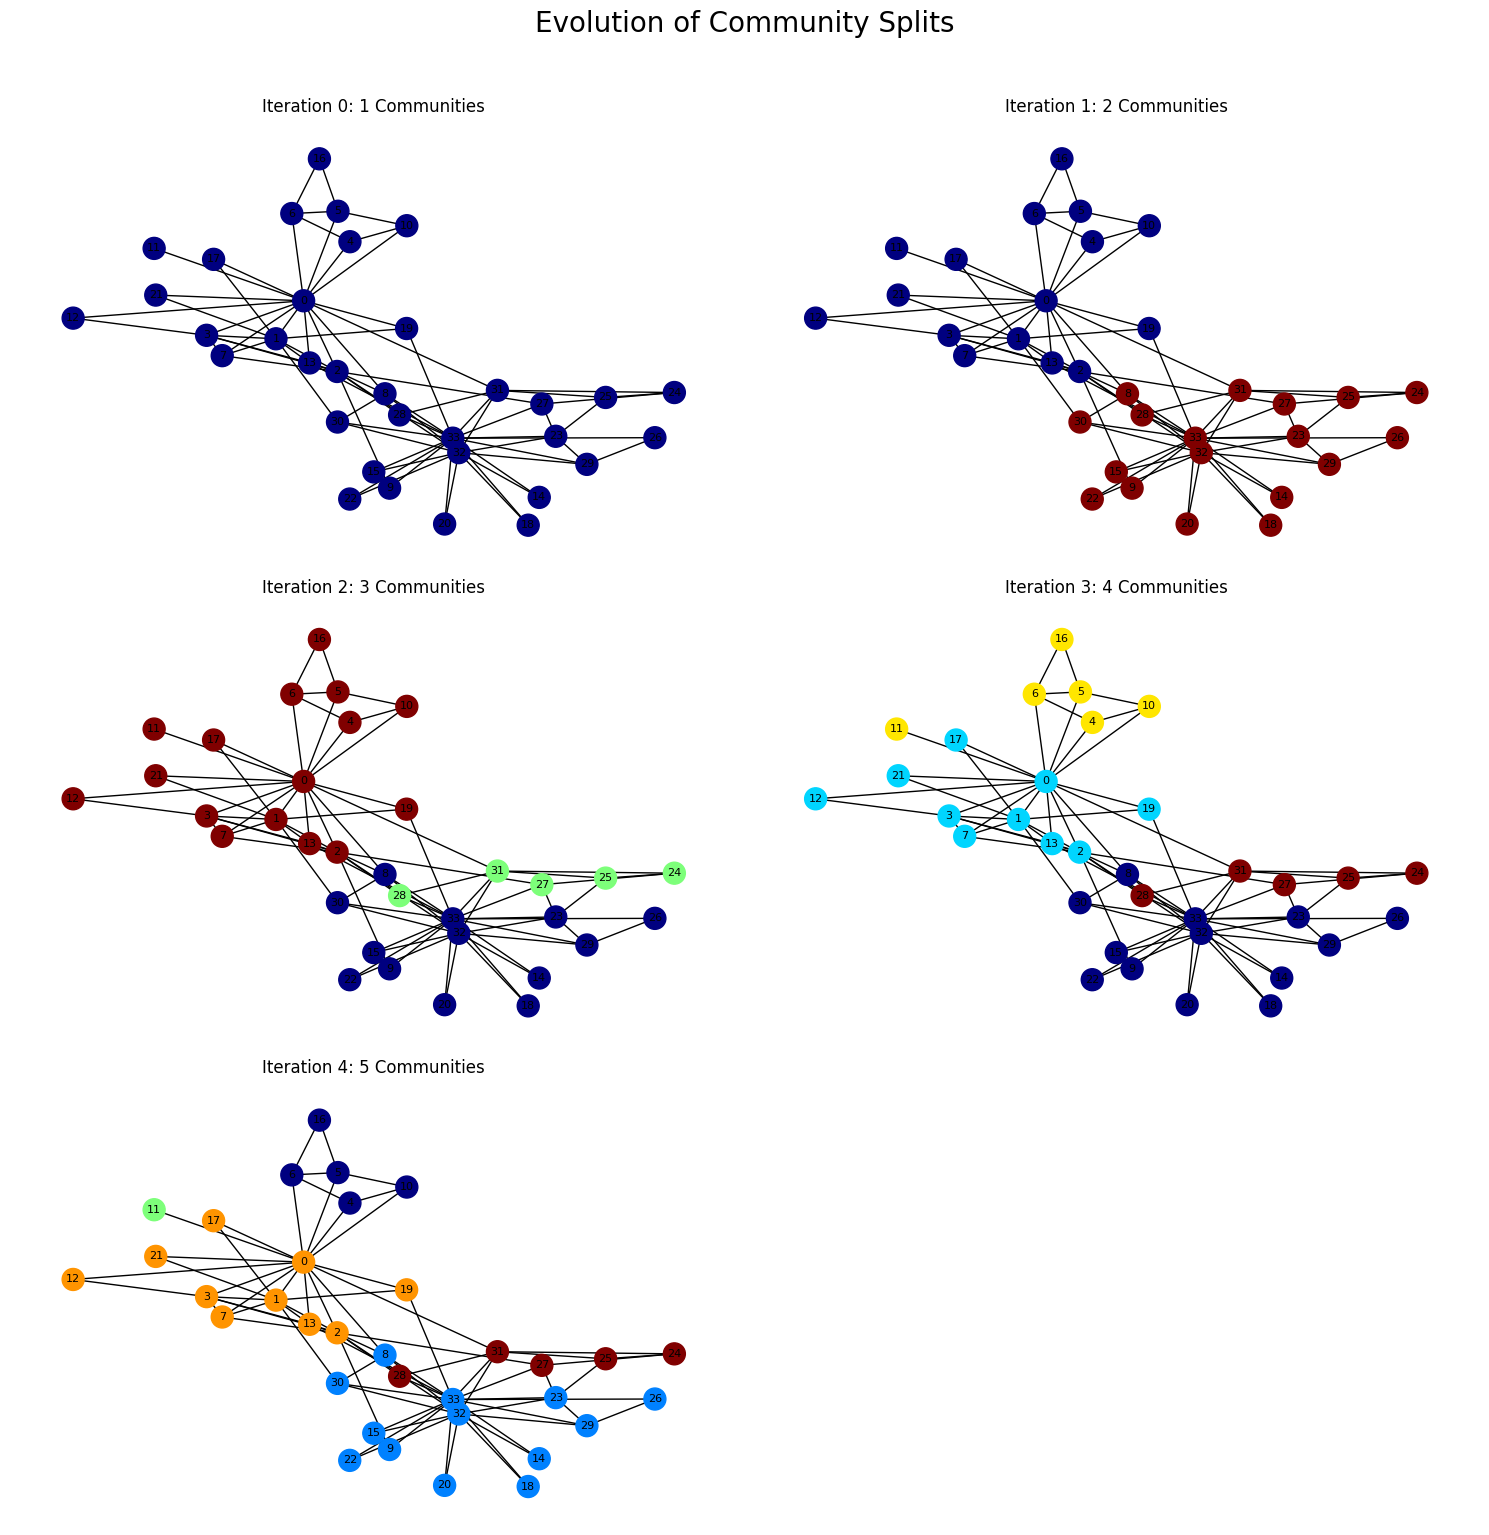

In [5]:
print("\n--- Visualizing Community Splits ---")

num_iterations = len(iteration_results)

# Create a figure to hold all subplots
# We'll plot Iteration 0, and then the final iterations
plt.figure(figsize=(15, 5 * (num_iterations // 2 + 1)))
plt.suptitle("Evolution of Community Splits", fontsize=20, y=1.02)

for i, result in enumerate(iteration_results):
    plt.subplot(num_iterations // 2 + 1, 2, i + 1)
    
    community_map = result['community_map']
    
    # Create a color list for nx.draw()
    # Nodes are guaranteed to be in order 0..N-1
    colors = [community_map[node] for node in G.nodes()]
    
    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_color=colors,
        cmap=plt.cm.jet,  # A 'colourfull' map
        node_size=250,
        font_size=8,
        font_color='black'
    )
    
    num_comms = len(set(colors))
    plt.title(f"Iteration {i}: {num_comms} Communities")

plt.tight_layout()
plt.show()

## 6. Visualization 2: Metric Evolution

This cell generates the second set of visualizations: line charts showing the evolution of node metrics over time.

First, it reformats the data from `iteration_results` into a new dictionary (`evolution`) that tracks each node's metric values across all iterations.

Then, it creates a 2x2 grid of subplots for the four metrics (Degree, Betweenness, Closeness, Clustering). Each plot shows the metric value for all 34 nodes (one line per node) across the iterations. As required by the assignment, these metrics are calculated on the *global, unchanging graph `G`*, so we expect the values for each node to be constant. This plot confirms that.


--- Visualizing Metric Evolution ---


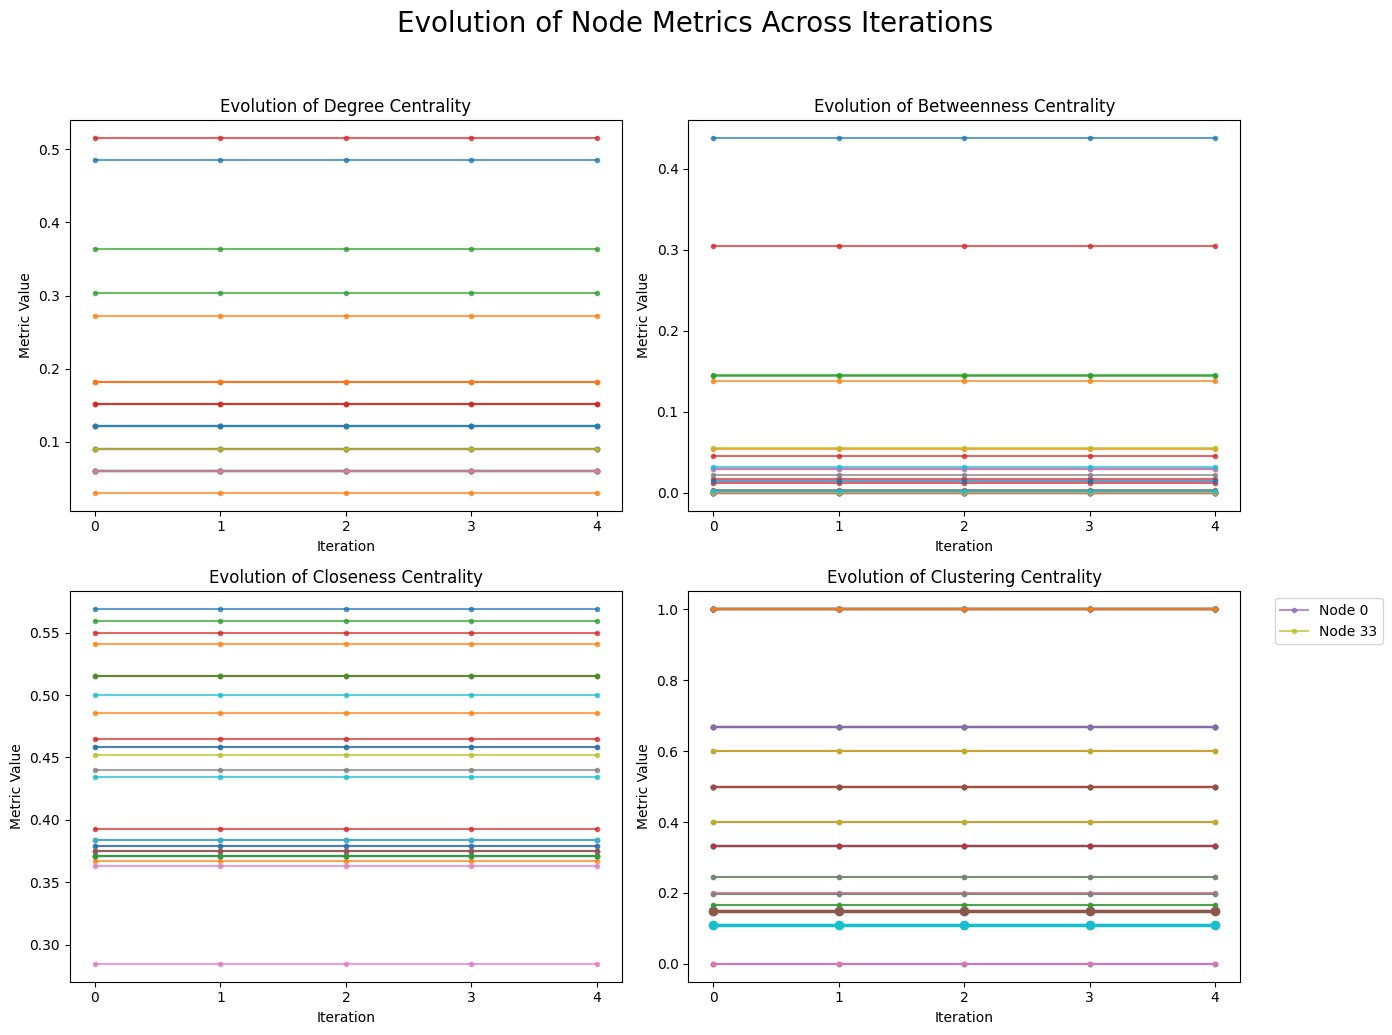

In [6]:
print("\n--- Visualizing Metric Evolution ---")

# We will plot the evolution of all 4 metrics 
metric_names = ['degree', 'betweenness', 'closeness', 'clustering']

# This dictionary will store the evolution data for easy plotting
evolution = {metric: {node: [] for node in G.nodes()} for metric in metric_names}

# Extract all data
for result in iteration_results:
    for metric in metric_names:
        for node in G.nodes():
            node_metric_val = result['metrics'][metric][node]
            evolution[metric][node].append(node_metric_val)

# --- Create the plots ---
plt.figure(figsize=(14, 10))
plt.suptitle("Evolution of Node Metrics Across Iterations", fontsize=20, y=1.03)

# Note: Degree centrality is constant, as the graph G doesn't change.
# The *other* metrics are shown for G, as requested ,
# not for the subgraphs.
# This plot will show degree is constant, which is correct.

for i, metric in enumerate(metric_names):
    plt.subplot(2, 2, i + 1)
    
    for node in G.nodes():
        # Get the node's metric values across all iterations
        values = evolution[metric][node]
        
        # Plot the line for this node
        plt.plot(values, marker='o', markersize=3, alpha=0.7)
    
    plt.title(f"Evolution of {metric.capitalize()} Centrality")
    plt.xlabel("Iteration")
    plt.ylabel("Metric Value")
    plt.xticks(range(len(iteration_results))) # Set x-ticks to be integers 0, 1, 2...

# Add a single, shared legend (it will be crowded, but shows all nodes)
# You can comment this out if it's too much
handles, labels = plt.gca().get_legend_handles_labels()
# To make it more readable, let's just label a few key nodes
# E.g., Node 0 (Mr. Hi) and Node 33 (Admin)
key_nodes_to_label = {0, 33}
for node in G.nodes():
    values = evolution[metric][node]
    label = f"Node {node}" if node in key_nodes_to_label else None
    plt.plot(values, marker='o', markersize=3, alpha=0.7, label=label)
    
    # Highlight the key nodes
    if node in key_nodes_to_label:
        plt.plot(values, marker='o', markersize=6, alpha=1.0, linewidth=2.5)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Discussion

*After running the code above, analyze the outputs and write your discussion here.*

**Key questions to answer:**
* **Which nodes consistently remain central across splits?**
    * Look at the "Evolution of Node Metrics" plots. Do any nodes (like Node 0 or Node 33, the instructor and administrator) *always* have high betweenness or closeness, even as the communities split?
* **How does community structure influence these metrics?**
    * This is a trick question from the assignment! The metrics computed are for the *global* graph `G` . They don't change because the graph itself doesn't change.
    * A more advanced analysis (which you could add) would be to compute these metrics *within* the subgraphs at each step. If you did that, you would see that a node that was a "bridge" (high betweenness) in the main graph might become a "center" (high closeness) *within* its new, smaller community.
    * However, following the prompt exactly, you will observe that the metrics are constant, as they are calculated on the full, unchanging graph `G`. Your discussion should note this.